In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('apartamentos_brasilia.csv', sep=';')

df.describe()

,preco,area_m2,quartos,banheiros,vagas,preco_m2
count,4.930000e+02,493.000000,492.000000,493.000000,391.000000,493.000000
mean,3.840731e+05,65.336714,2.186992,1.584178,1.150895,5787.937120
std,3.224745e+05,27.853643,0.616799,0.745933,0.453186,2938.804082
min,1.500000e+04,27.000000,1.000000,1.000000,0.000000,278.000000
25%,2.190000e+05,49.000000,2.000000,1.000000,1.000000,3778.000000
50%,3.120000e+05,58.000000,2.000000,1.000000,1.000000,5439.000000
75%,4.500000e+05,71.000000,3.000000,2.000000,1.000000,7411.000000
max,3.003280e+06,243.000000,4.000000,5.000000,4.000000,18539.000000


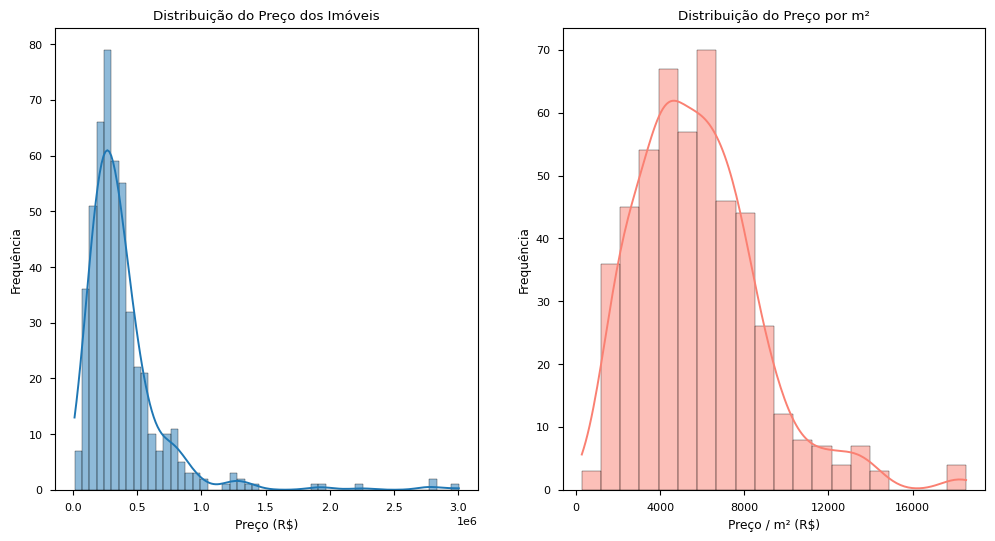

In [50]:
plt.style.use('seaborn-v0_8-paper')
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histograma do Preço Total
sns.histplot(df['preco'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Preço dos Imóveis')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')

# Histograma do Preço/m²
ax = sns.histplot(df['preco_m2'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição do Preço por m²')
axes[1].set_xlabel('Preço / m² (R$)')
axes[1].set_ylabel('Frequência')
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
plt.savefig("distribuicao.pdf", format="pdf", bbox_inches='tight')

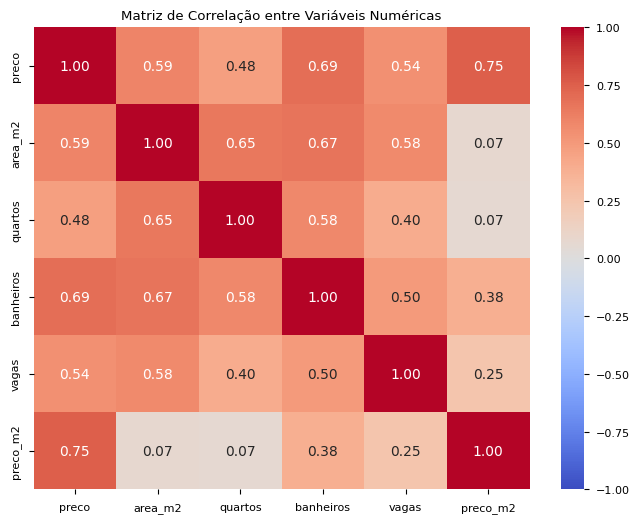

In [51]:
colunas_numericas = df.select_dtypes(include=[np.number])
matriz_corr = colunas_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.savefig("heatmap.pdf", format="pdf", bbox_inches='tight')

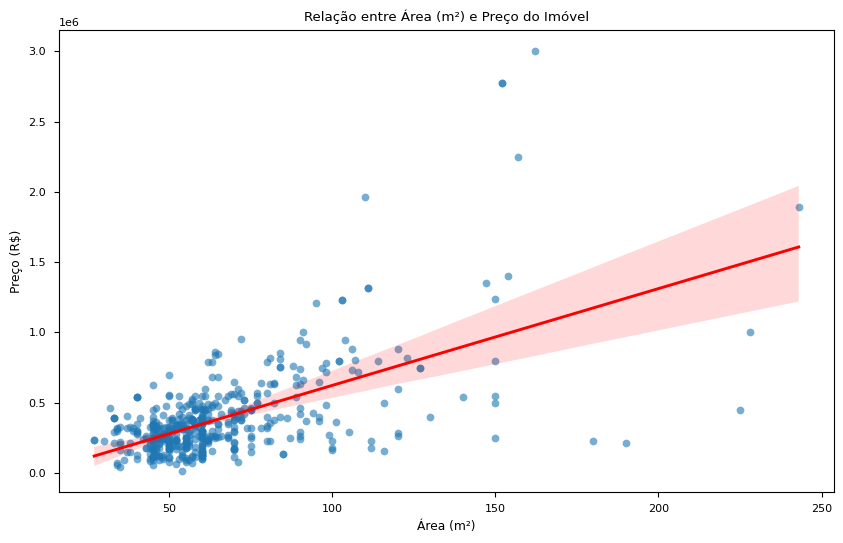

In [52]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='area_m2',
    y='preco',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('Relação entre Área (m²) e Preço do Imóvel')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (R$)')
plt.savefig("regplot.pdf", format="pdf", bbox_inches='tight')

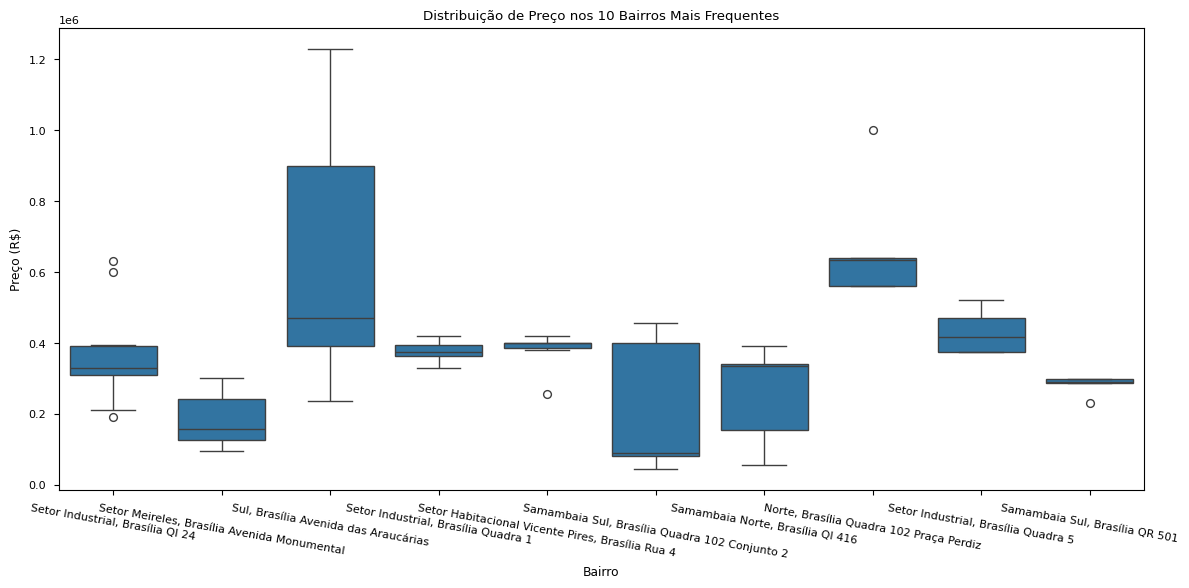

In [53]:
top_10_bairros = df['bairro'].value_counts().head(10).index
df_top10 = df[df['bairro'].isin(top_10_bairros)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top10,
    x='bairro',
    y='preco',
    order=top_10_bairros
)
plt.title('Distribuição de Preço nos 10 Bairros Mais Frequentes')
plt.xlabel('Bairro')
plt.ylabel('Preço (R$)')
plt.xticks(rotation=350)
plt.savefig("boxplot.pdf", format="pdf", bbox_inches='tight')

In [54]:
features_base = ['area_m2', 'quartos', 'banheiros', 'vagas']

# Criando variáveis dummies para a coluna de bairro
df_model = pd.get_dummies(df, columns=['bairro'], drop_first=True)

bairro_cols = [col for col in df_model.columns if col.startswith('bairro_')]
X_cols = features_base + bairro_cols

X = df_model[X_cols]
y = df_model['preco']

# Trata NaNs na variável alvo (y), se existirem
if y.isna().sum() > 0:
    idx_validos = y.dropna().index
    X = X.loc[idx_validos]
    y = y.loc[idx_validos]

# Divisão dos dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Estratégia 'median' preenche NaNs com a mediana de cada coluna
imputer = SimpleImputer(strategy='median')

# Ajusta e transforma nos dados de treino
X_train_imputed = imputer.fit_transform(X_train)

# Apenas transforma os dados de teste com a estatística calculada no treino
X_test_imputed = imputer.transform(X_test)

# Converte de volta para DataFrame mantendo os nomes das colunas
X_train_clean = pd.DataFrame(X_train_imputed, columns=X_cols, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_imputed, columns=X_cols, index=X_test.index)

# A) Regressão Linear Múltipla
model_lr = LinearRegression()
model_lr.fit(X_train_clean, y_train)
y_pred_lr = model_lr.predict(X_test_clean)

# B) Regressão Linear com Transformação Logarítmica em preco
y_train_log = np.log(y_train)
model_log = LinearRegression()
model_log.fit(X_train_clean, y_train_log)
y_pred_log = np.exp(model_log.predict(X_test_clean))

# C) Ridge (Regularização L2)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_clean, y_train)
y_pred_ridge = model_ridge.predict(X_test_clean)

# D) Lasso (Regularização L1)
model_lasso = Lasso(alpha=100.0, max_iter=10000)
model_lasso.fit(X_train_clean, y_train)
y_pred_lasso = model_lasso.predict(X_test_clean)

In [55]:
lr_coefs = pd.DataFrame(zip(X.columns, model_lr.coef_))
log_coefs = pd.DataFrame(zip(X.columns, model_log.coef_))
ridge_coefs = pd.DataFrame(zip(X.columns, model_ridge.coef_))
lasso_coefs = pd.DataFrame(zip(X.columns, model_lasso.coef_))

In [56]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Modelo": nome_modelo,
        "R²": f"{r2:.4f}",
        "MAE (R$)": f"R$ {mae:,.2f}",
        "RMSE (R$)": f"R$ {rmse:,.2f}"
    }

resultados = [
    calcular_metricas(y_test, y_pred_lr, "Regressão Linear Múltipla"),
    calcular_metricas(y_test, y_pred_log, "Regressão com log(preco)"),
    calcular_metricas(y_test, y_pred_ridge, "Ridge (L2)"),
    calcular_metricas(y_test, y_pred_lasso, "Lasso (L1)")
]

df_resultados = pd.DataFrame(resultados)
print("--- Comparativo de Desempenho dos Modelos ---")
print(df_resultados.to_string(index=False))

--- Comparativo de Desempenho dos Modelos ---
                   Modelo     R²      MAE (R$)     RMSE (R$)
Regressão Linear Múltipla 0.5021 R$ 187,288.53 R$ 256,269.40
 Regressão com log(preco) 0.7185 R$ 127,706.24 R$ 192,699.36
               Ridge (L2) 0.7659 R$ 112,364.83 R$ 175,736.08
               Lasso (L1) 0.7992  R$ 99,321.59 R$ 162,739.62


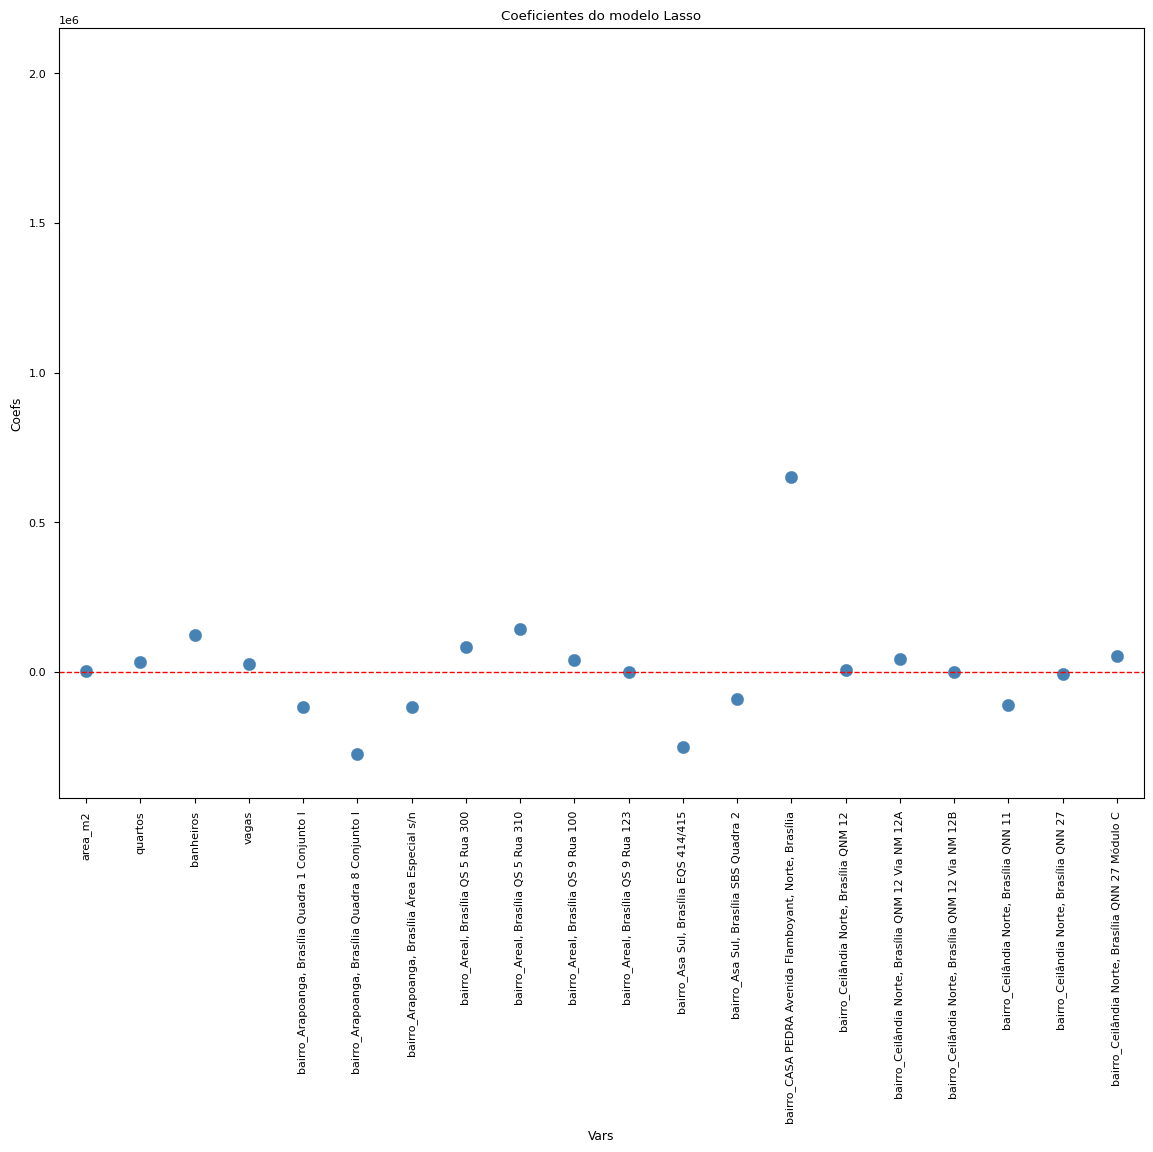

In [95]:
# Código abaixo foi adaptado do site:
# https://medium.com/analytics-vidhya/create-your-own-coefficient-plot-function-in-python-aadb9fe27a77

fig, ax = plt.subplots(figsize=(14, 10))

lasso_coefs.head(20).plot(
    x=0, y=1, kind='bar',
    ax=ax, color='none', ecolor='steelblue',
    capsize=0, legend=False
)

plt.title('Coeficientes do modelo Lasso')
ax.set_ylabel('Coefs')
ax.set_xlabel('Vars')

ax.scatter(
    x=lasso_coefs[0],
    marker='o', s=80,
    y=lasso_coefs[1], color='steelblue'
)

ax.axhline(
    y=0, linestyle='--',
    color='red', linewidth=1
)

plt.savefig("coefs.pdf", format="pdf", bbox_inches='tight')